# ☕ CaféBR — Análise Exploratória de Vendas (2024–2025)

**Autor:** analista de dados · **Ferramentas:** Python · pandas · SQL (sqlite3) · matplotlib · seaborn

---

## 1. Introdução

A **CaféBR** é uma rede fictícia de cafeterias com 5 unidades em capitais brasileiras
(São Paulo, Rio de Janeiro, Belo Horizonte, Curitiba e Porto Alegre). A diretoria quer
entender o comportamento de vendas para orientar decisões de estoque, promoções e
expansão.

### Pergunta de negócio
> **Onde, quando e como a CaféBR vende mais — e o que isso sugere para aumentar a receita?**

### Perguntas de análise
1. Quais **lojas** e **produtos** mais faturam?
2. Como a **receita evolui mês a mês**? Existe sazonalidade?
3. Qual o **ticket médio por canal** (balcão, app, delivery)?
4. Qual **forma de pagamento** domina?
5. Há diferença de vendas por **turno** e **dia da semana**?

> Todos os dados são **sintéticos** e gerados offline (`gerar_dados.py`). Nada depende
> de downloads externos ou chaves de API.

## 2. Carregamento e visão geral

Importamos as bibliotecas, configuramos o estilo dos gráficos e carregamos o CSV bruto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Estilo visual consistente para todos os gráficos
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# Formatação de valores em Real (R$) no padrão brasileiro: 1.234,56
def reais(valor):
    return ("R$ " + f"{valor:,.2f}").replace(",", "X").replace(".", ",").replace("X", ".")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("dados/vendas_cafebr.csv")
print(f"Formato: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

Formato: 2015 linhas x 8 colunas


,data,loja,produto,categoria,quantidade,preco_unitario,forma_pagamento,canal
0,2024-08-16 16:11,Porto Alegre - Moinhos,Café Coado,Bebida Quente,1,4.78,Cartão,Balcão
1,2024-11-10 08:09,Curitiba - Batel,Café Gelado,Bebida Gelada,1,12.53,Pix,App
2,2024-12-08 07:38,São Paulo - Paulista,Café Expresso,Bebida Quente,1,6.16,Cartão,App
3,2024-12-12 10:14,São Paulo - Paulista,Bolo de Cenoura,Comida,1,9.38,Cartão,Balcão
4,2024-01-13 12:59,São Paulo - Paulista,Chocolate Quente,Bebida Quente,1,12.66,Cartão,Balcão


Estrutura, tipos de dados e uso de memória:

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2015 entries, 0 to 2014
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   data             2015 non-null   str    
 1   loja             2015 non-null   str    
 2   produto          2015 non-null   str    
 3   categoria        2015 non-null   str    
 4   quantidade       2015 non-null   int64  
 5   preco_unitario   2015 non-null   float64
 6   forma_pagamento  1990 non-null   str    
 7   canal            2015 non-null   str    
dtypes: float64(1), int64(1), str(6)
memory usage: 126.1 KB


Estatísticas descritivas das colunas numéricas:

In [4]:
df.describe()

,quantidade,preco_unitario
count,2015.000000,2015.000000
mean,1.618859,10.483355
std,0.820929,3.140886
min,1.000000,4.750000
25%,1.000000,7.480000
50%,1.000000,10.990000
75%,2.000000,12.555000
max,4.000000,17.270000


Checagem de valores nulos e de duplicatas — o que precisará de limpeza:

In [5]:
print("Nulos por coluna:")
print(df.isna().sum())
print(f"\nLinhas duplicadas: {df.duplicated().sum()}")

Nulos por coluna:
data                0
loja                0
produto             0
categoria           0
quantidade          0
preco_unitario      0
forma_pagamento    25
canal               0
dtype: int64

Linhas duplicadas: 15


## 3. Limpeza e preparação

Encontramos duas questões típicas de dados reais:

- **Valores nulos** em `forma_pagamento`.
- **Linhas duplicadas** (registros repetidos por erro de sistema).

Estratégia:
- Remover duplicatas exatas.
- Preencher `forma_pagamento` nula com a moda (categoria mais frequente) — decisão
  conservadora, já que representa poucos registros.
- Converter `data` para `datetime` e criar colunas derivadas para a análise:
  `receita`, `mes`, `dia_semana` e `turno`.

In [6]:
antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicatas removidas: {antes - len(df)}")

# Preencher nulos de forma_pagamento com a moda
moda_pag = df["forma_pagamento"].mode()[0]
n_nulos = df["forma_pagamento"].isna().sum()
df["forma_pagamento"] = df["forma_pagamento"].fillna(moda_pag)
print(f"Nulos preenchidos em forma_pagamento: {n_nulos} (moda = '{moda_pag}')")

print("\nNulos restantes:", int(df.isna().sum().sum()))

Duplicatas removidas: 15
Nulos preenchidos em forma_pagamento: 25 (moda = 'Cartão')

Nulos restantes: 0


In [7]:
# Conversão de tipos e colunas derivadas
df["data"] = pd.to_datetime(df["data"])

df["receita"] = df["quantidade"] * df["preco_unitario"]
df["mes"] = df["data"].dt.to_period("M").astype(str)          # ex.: 2024-07
df["hora"] = df["data"].dt.hour

dias_pt = {0: "Seg", 1: "Ter", 2: "Qua", 3: "Qui", 4: "Sex", 5: "Sáb", 6: "Dom"}
df["dia_semana"] = df["data"].dt.dayofweek.map(dias_pt)

def classificar_turno(h):
    if 6 <= h < 12:
        return "Manhã"
    if 12 <= h < 18:
        return "Tarde"
    return "Noite"

df["turno"] = df["hora"].apply(classificar_turno)

df[["data", "loja", "produto", "quantidade", "preco_unitario",
    "receita", "mes", "dia_semana", "turno"]].head()

,data,loja,produto,quantidade,preco_unitario,receita,mes,dia_semana,turno
0,2024-08-16 16:11:00,Porto Alegre - Moinhos,Café Coado,1,4.78,4.78,2024-08,Sex,Tarde
1,2024-11-10 08:09:00,Curitiba - Batel,Café Gelado,1,12.53,12.53,2024-11,Dom,Manhã
2,2024-12-08 07:38:00,São Paulo - Paulista,Café Expresso,1,6.16,6.16,2024-12,Dom,Manhã
3,2024-12-12 10:14:00,São Paulo - Paulista,Bolo de Cenoura,1,9.38,9.38,2024-12,Qui,Manhã
4,2024-01-13 12:59:00,São Paulo - Paulista,Chocolate Quente,1,12.66,12.66,2024-01,Sáb,Tarde


In [8]:
print("Receita total no período:", reais(df["receita"].sum()))
print("Ticket médio por venda:", reais(df["receita"].mean()))
print("Período:", df["data"].min().date(), "a", df["data"].max().date())

Receita total no período: R$ 33.845,53
Ticket médio por venda: R$ 16,92


Período: 2024-01-01 a 2025-12-31


## 4. Análise

Cada pergunta abaixo tem um **gráfico** e um **parágrafo de leitura** do resultado.

### 4.1 Quais lojas faturam mais?

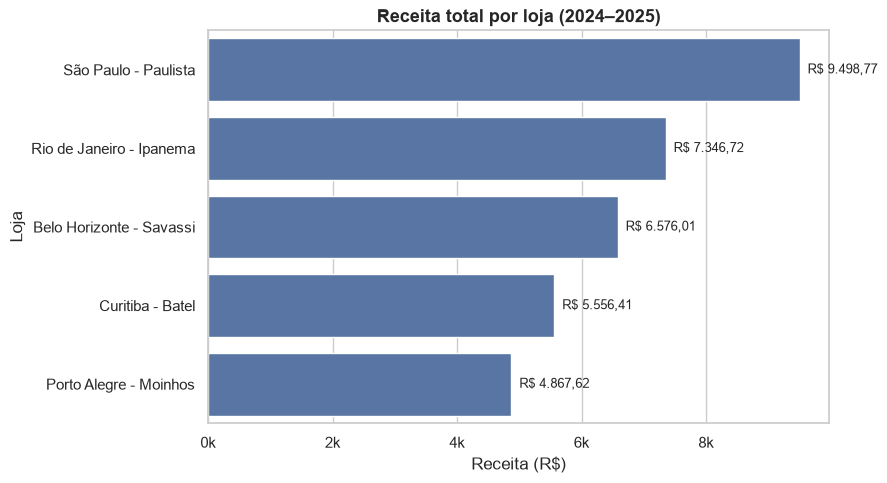

São Paulo - Paulista             R$ 9.498,77
Rio de Janeiro - Ipanema         R$ 7.346,72
Belo Horizonte - Savassi         R$ 6.576,01
Curitiba - Batel                 R$ 5.556,41
Porto Alegre - Moinhos           R$ 4.867,62


In [9]:
receita_loja = df.groupby("loja")["receita"].sum().sort_values(ascending=False)

ax = sns.barplot(x=receita_loja.values, y=receita_loja.index, color="#4C72B0")
ax.set_title("Receita total por loja (2024–2025)")
ax.set_xlabel("Receita (R$)")
ax.set_ylabel("Loja")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
for i, v in enumerate(receita_loja.values):
    ax.text(v, i, "  " + reais(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

for loja, v in receita_loja.items():
    print(f"{loja:32s} {reais(v)}")

**Leitura:** a unidade **São Paulo - Paulista** lidera a receita com folga, seguida por
Rio de Janeiro - Ipanema. As três primeiras lojas concentram a maior parte do
faturamento. As unidades do Sul (Curitiba e Porto Alegre) fecham o ranking — candidatas
naturais a ações de marketing local para reduzir a distância para as líderes.

### 4.2 Quais produtos vendem mais?

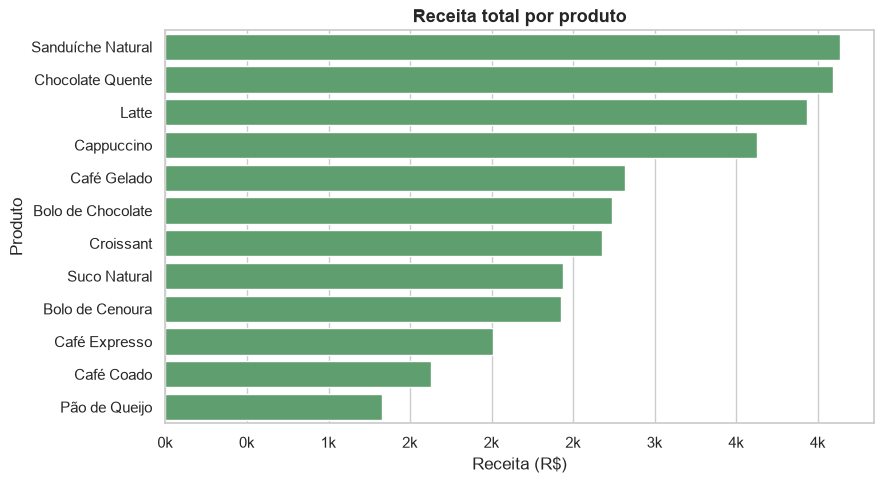

Top 5 produtos por receita:
  Sanduíche Natural    R$ 4.136,68
  Chocolate Quente     R$ 4.093,49
  Latte                R$ 3.930,94
  Cappuccino           R$ 3.625,71
  Café Gelado          R$ 2.818,10

Receita por categoria:
  Bebida Quente    R$ 15.286,79
  Comida           R$ 13.301,97
  Bebida Gelada    R$ 5.256,77


In [10]:
receita_prod = df.groupby("produto")["receita"].sum().sort_values(ascending=False)

ax = sns.barplot(x=receita_prod.values, y=receita_prod.index, color="#55A868")
ax.set_title("Receita total por produto")
ax.set_xlabel("Receita (R$)")
ax.set_ylabel("Produto")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
plt.tight_layout()
plt.show()

print("Top 5 produtos por receita:")
for p, v in receita_prod.head().items():
    print(f"  {p:20s} {reais(v)}")

# Receita por categoria
print("\nReceita por categoria:")
for c, v in df.groupby("categoria")["receita"].sum().sort_values(ascending=False).items():
    print(f"  {c:16s} {reais(v)}")

**Leitura:** as **bebidas quentes** (cappuccino, latte, chocolate quente) e os itens de
maior ticket como o **sanduíche natural** puxam a receita. Produtos de ticket baixo e
alto giro (café expresso, pão de queijo) aparecem em volume, mas pesam menos no
faturamento. A categoria **Bebida Quente** é o coração do negócio.

### 4.3 Como a receita evolui mês a mês?

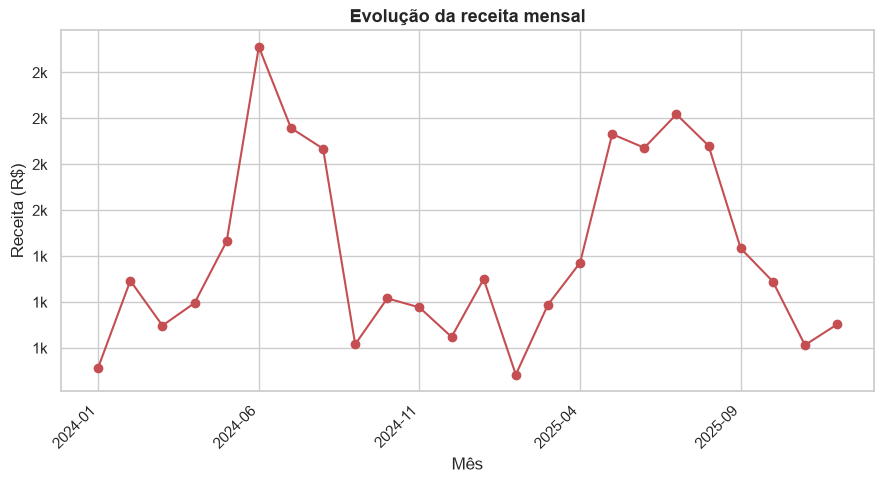

Receita por mês-calendário (soma 2024+2025):
  mês 01: R$ 2.214,69
  mês 02: R$ 2.176,91
  mês 03: R$ 2.285,90
  mês 04: R$ 2.567,03
  mês 05: R$ 3.396,43
  mês 06: R$ 4.183,75
  mês 07: R$ 3.976,12
  mês 08: R$ 3.749,21
  mês 09: R$ 2.449,95
  mês 10: R$ 2.505,73
  mês 11: R$ 2.189,28
  mês 12: R$ 2.150,53


In [11]:
receita_mes = df.groupby("mes")["receita"].sum()

ax = receita_mes.plot(marker="o", color="#C44E52")
ax.set_title("Evolução da receita mensal")
ax.set_xlabel("Mês")
ax.set_ylabel("Receita (R$)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Receita média por mês do ano (agregando 2024+2025) para ver sazonalidade
df["mes_num"] = df["data"].dt.month
saz = df.groupby("mes_num")["receita"].sum()
print("Receita por mês-calendário (soma 2024+2025):")
for m, v in saz.items():
    print(f"  mês {m:02d}: {reais(v)}")

**Leitura:** a receita mostra **sazonalidade de inverno** — os meses de **junho, julho e
agosto** concentram os maiores valores, coerente com o consumo de bebidas quentes no
frio. O verão (dezembro a fevereiro) é o vale. Isso sugere reforçar estoque e equipe no
inverno e criar campanhas de bebidas geladas para sustentar a receita no verão.

### 4.4 Qual o ticket médio por canal?

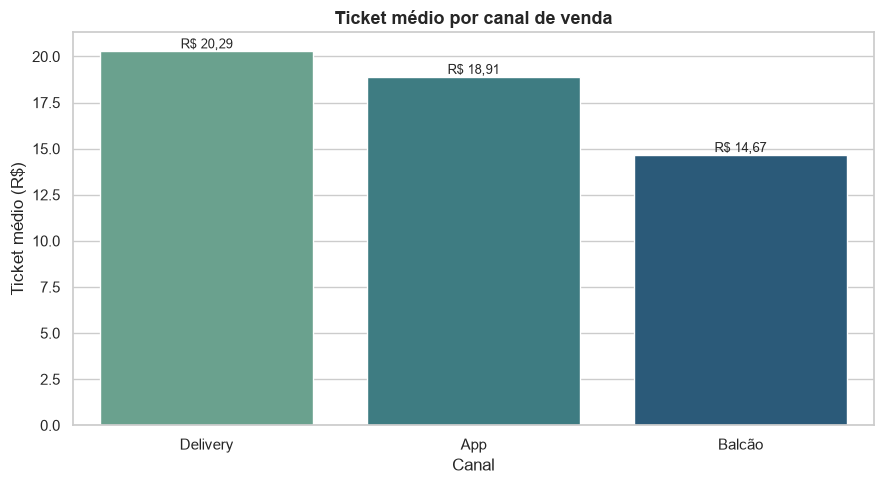

Participação de cada canal na receita total:
  Balcão      46.0%
  App         31.7%
  Delivery    22.4%


In [12]:
ticket_canal = df.groupby("canal")["receita"].mean().sort_values(ascending=False)

ax = sns.barplot(x=ticket_canal.index, y=ticket_canal.values,
                 hue=ticket_canal.index, palette="crest", legend=False)
ax.set_title("Ticket médio por canal de venda")
ax.set_xlabel("Canal")
ax.set_ylabel("Ticket médio (R$)")
for i, v in enumerate(ticket_canal.values):
    ax.text(i, v, reais(v), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print("Participação de cada canal na receita total:")
part = df.groupby("canal")["receita"].sum()
for c, v in (part / part.sum() * 100).sort_values(ascending=False).items():
    print(f"  {c:10s} {v:5.1f}%")

**Leitura:** o **delivery** e o **app** tendem a apresentar ticket médio maior que o
balcão — pedidos digitais costumam agregar mais itens por compra. Ainda assim, o
**balcão** responde pela maior fatia da receita total por volume. Conclusão prática:
os canais digitais são alavancas de ticket; vale incentivar combos e itens adicionais no
app para elevar ainda mais o valor por pedido.

### 4.5 Qual forma de pagamento domina?

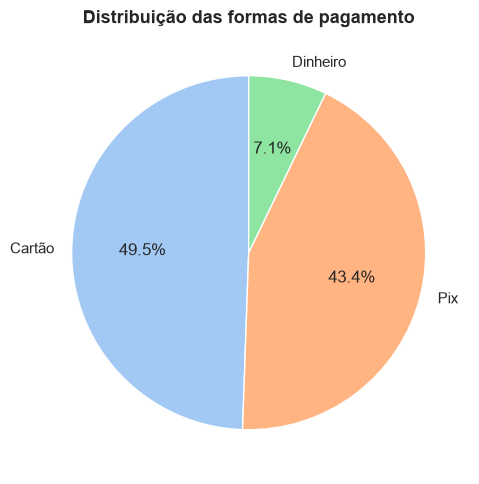

Transações por forma de pagamento:
  Cartão      989  (49.5%)
  Pix         868  (43.4%)
  Dinheiro    143  (7.1%)


In [13]:
pag = df["forma_pagamento"].value_counts()

ax = pag.plot(kind="pie", autopct="%1.1f%%", startangle=90,
              colors=sns.color_palette("pastel"), ylabel="")
ax.set_title("Distribuição das formas de pagamento")
plt.tight_layout()
plt.show()

print("Transações por forma de pagamento:")
for f, n in pag.items():
    print(f"  {f:10s} {n:4d}  ({n/len(df)*100:.1f}%)")

**Leitura:** **cartão** e **Pix** dominam os pagamentos, com o dinheiro em queda —
padrão típico do varejo brasileiro pós-popularização do Pix. Como Pix tem custo de
transação baixíssimo, incentivá-lo (ex.: pequeno desconto) pode reduzir taxas de cartão
sem afastar o cliente.

### 4.6 Há diferença por turno e dia da semana?

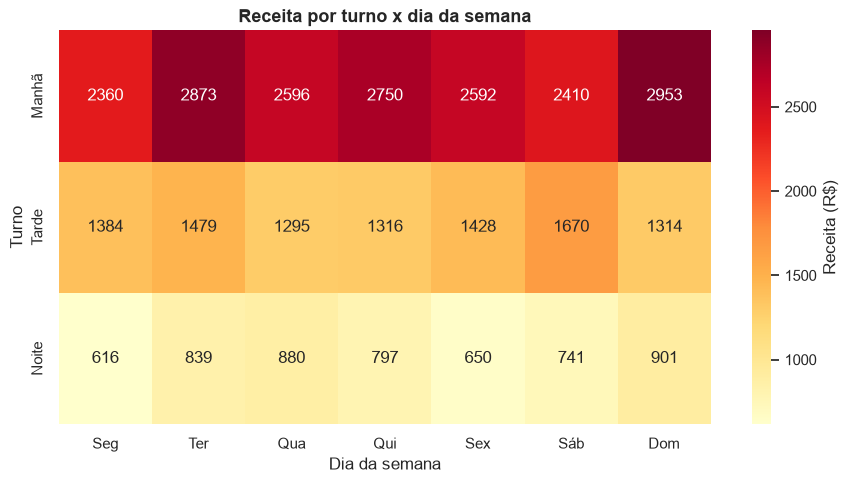

Receita por turno:
  Manhã    R$ 18.533,99
  Tarde    R$ 9.887,63
  Noite    R$ 5.423,91


In [14]:
ordem_dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
ordem_turnos = ["Manhã", "Tarde", "Noite"]

tabela = (df.pivot_table(index="turno", columns="dia_semana",
                         values="receita", aggfunc="sum")
            .reindex(index=ordem_turnos, columns=ordem_dias))

ax = sns.heatmap(tabela, annot=True, fmt=".0f", cmap="YlOrRd",
                 cbar_kws={"label": "Receita (R$)"})
ax.set_title("Receita por turno x dia da semana")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Turno")
plt.tight_layout()
plt.show()

print("Receita por turno:")
for t, v in df.groupby("turno")["receita"].sum().reindex(ordem_turnos).items():
    print(f"  {t:8s} {reais(v)}")

**Leitura:** a **manhã** é disparado o turno mais forte — o pico clássico do café antes
do trabalho. Os dias de semana concentram o movimento, com leve queda no fim de semana.
O turno da noite é o mais fraco. Recomendação: garantir equipe e estoque completos no
pico da manhã e testar promoções à tarde/noite para suavizar a ociosidade.

## 5. Consulta em SQL (sqlite3)

Para demonstrar domínio de SQL, carregamos o DataFrame em um banco **SQLite em memória**
e respondemos a uma pergunta com uma consulta: **o produto campeão de receita em cada
loja**, usando `GROUP BY`, agregação e uma *window function* (`RANK`).

In [15]:
import sqlite3

con = sqlite3.connect(":memory:")
df.to_sql("vendas", con, index=False, if_exists="replace")

consulta = '''
WITH receita_produto AS (
    SELECT
        loja,
        produto,
        ROUND(SUM(quantidade * preco_unitario), 2) AS receita,
        RANK() OVER (
            PARTITION BY loja
            ORDER BY SUM(quantidade * preco_unitario) DESC
        ) AS posicao
    FROM vendas
    GROUP BY loja, produto
)
SELECT loja, produto, receita
FROM receita_produto
WHERE posicao = 1
ORDER BY receita DESC;
'''

top_por_loja = pd.read_sql_query(consulta, con)
con.close()
top_por_loja

,loja,produto,receita
0,São Paulo - Paulista,Chocolate Quente,1440.36
1,Rio de Janeiro - Ipanema,Sanduíche Natural,918.41
2,Belo Horizonte - Savassi,Latte,845.85
3,Curitiba - Batel,Sanduíche Natural,797.13
4,Porto Alegre - Moinhos,Latte,725.02


**Leitura:** a consulta revela o produto **líder de receita em cada unidade**. Bebidas
quentes de maior ticket (cappuccino/latte) tendem a aparecer no topo, confirmando via SQL
o que os gráficos mostraram: o mix de bebidas quentes é o motor de faturamento em todas
as praças.

## 6. Conclusões e recomendações

Síntese acionável para a diretoria da CaféBR:

1. **Concentração geográfica.** São Paulo - Paulista e Rio de Janeiro - Ipanema puxam a
   receita. *Ação:* replicar as boas práticas dessas lojas nas unidades do Sul e avaliar
   investimento de marketing local em Curitiba e Porto Alegre.

2. **Sazonalidade de inverno é forte e previsível.** Junho–agosto são o pico graças às
   bebidas quentes. *Ação:* planejar estoque/escala para o inverno e lançar linha gelada
   promocional no verão para suavizar o vale.

3. **A manhã é o coração do negócio.** O pico matinal em dias úteis domina. *Ação:*
   garantir equipe completa das 7h às 11h e testar "happy hour do café" à tarde/noite
   para ocupar a capacidade ociosa.

4. **Canais digitais têm ticket maior.** App e delivery elevam o valor por pedido.
   *Ação:* incentivar combos e itens adicionais no app para aumentar ainda mais o ticket.

5. **Pix já rivaliza com o cartão.** *Ação:* estimular o Pix (ex.: mimo/desconto pontual)
   para reduzir custos de adquirência sem perder conversão.

---
*Análise reprodutível: `python gerar_dados.py` recria o CSV; o notebook roda de cima a
baixo sem dependências externas.*